In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('Cleaned/finaldataset.csv')
df.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [3]:
df.drop(columns=['date'], inplace=True)
df.head()

,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [4]:
median_rate = df['FEDRates'].median()
df['FEDRates_Binary'] = df['FEDRates'].apply(lambda x: 0 if x <= median_rate else 1)

In [5]:
X = df.drop(columns=['FEDRates', 'FEDRates_Binary'])
y = df['FEDRates_Binary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
param_grid = [
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': 20}
]

In [10]:
results = []

for params in param_grid:
    model = RandomForestClassifier(n_estimators=params['n_estimators'],
                                    max_depth=params['max_depth'],
                                    random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

In [11]:
results_df = pd.DataFrame(results)

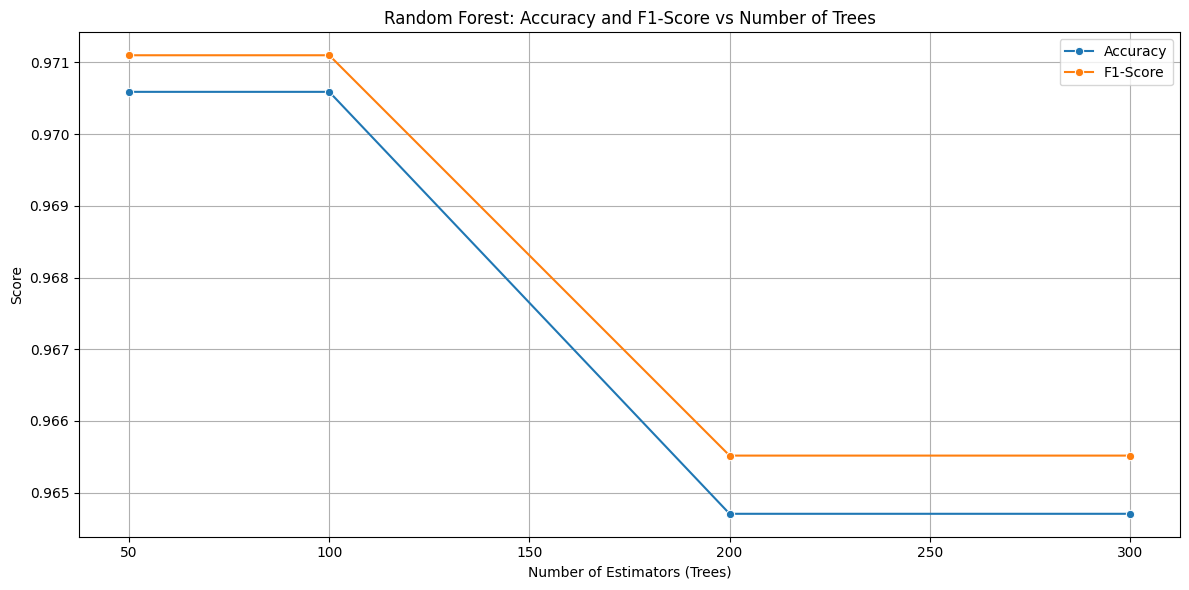

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='n_estimators', y='Accuracy', marker='o', label='Accuracy')
sns.lineplot(data=results_df, x='n_estimators', y='F1-Score', marker='o', label='F1-Score')
plt.title('Random Forest: Accuracy and F1-Score vs Number of Trees')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
print("\nBest Random Forest Settings:")
print(results_df.sort_values(by='Accuracy', ascending=False).head(1))


Best Random Forest Settings:
   n_estimators  max_depth  Accuracy  Precision    Recall  F1-Score
0            50        5.0  0.970588   0.954545  0.988235  0.971098


In [16]:
best_params = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]
best_model = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

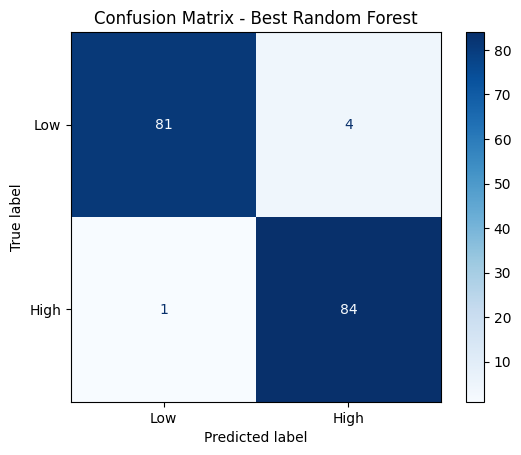

In [19]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Best Random Forest')
plt.show()

C:\Users\Sangram More\AppData\Local\Temp\ipykernel_2940\306659195.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


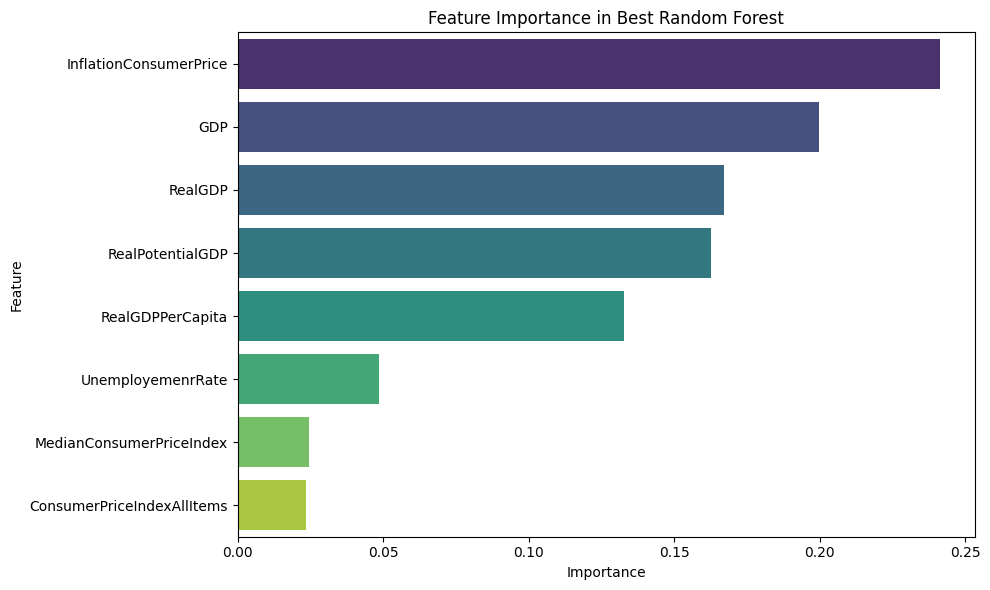

In [21]:
importances = best_model.feature_importances_
feature_names = X.columns

# Create a DataFrame
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Best Random Forest')
plt.tight_layout()
plt.show()